Importing the libraries

In [21]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

Dataset loading

In [22]:
try:
    df = pd.read_csv('cybersecurity_risk_advanced.csv')
    print("Dataset loaded successfully!")
except FileNotFoundError:
    print("Error: Ensure 'cybersecurity_risk_advanced.csv' is in the same folder as this script.")

Dataset loaded successfully!


checking for missing values

In [23]:
df.isnull().sum()

attempt_count              0
avg_time_gap               0
time_gap_std               0
is_common_pass             0
device_type                0
is_night_time              0
location_id                0
ip_reputation              0
vpn_detected               0
port_used                  0
typing_speed               0
session_duration           0
last_login_diff            0
failed_to_success_ratio    0
is_new_location            0
entropy_of_attempts        0
user_agent_score           0
risk_label                 0
dtype: int64

checking duplicates

In [24]:
df.duplicated().sum()

np.int64(0)

Feature Engineering

In [25]:
# Let's create 'burst_score' (Product of frequency and lack of variance)
# High attempts + Low time variance = High Burst Score (Bot behavior)
df['burst_score'] = (df['attempt_count'] / (df['avg_time_gap'] + 0.1)) * (1 / (df['time_gap_std'] + 0.01))

In [26]:
# Let's create 'network_risk_index' (Combining VPN and IP Reputation)
df['network_risk_index'] = df['vpn_detected'] * (1 - df['ip_reputation'])

print(f"Feature Engineering complete. Current feature count: {df.shape[1]}")

Feature Engineering complete. Current feature count: 20


In [27]:
df.shape

(50000, 20)

In [28]:
df.columns

Index(['attempt_count', 'avg_time_gap', 'time_gap_std', 'is_common_pass',
       'device_type', 'is_night_time', 'location_id', 'ip_reputation',
       'vpn_detected', 'port_used', 'typing_speed', 'session_duration',
       'last_login_diff', 'failed_to_success_ratio', 'is_new_location',
       'entropy_of_attempts', 'user_agent_score', 'risk_label', 'burst_score',
       'network_risk_index'],
      dtype='object')

Data preprocessing

In [29]:
# define features (X) and target (y)
X = df.drop('risk_label', axis=1)
y = df['risk_label']

In [30]:
# Standardizing numeric values (Mean=0, Std=1)
# This is crucial so features like 'port_used' (8080) don't dominate 'ip_reputation' (0.5)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [31]:
# Convert back to DataFrame for easier EDA later
X_final = pd.DataFrame(X_scaled, columns=X.columns)

print("\n--- Preprocessing Complete ---")
print("Data is now standardized and features are engineered.")


--- Preprocessing Complete ---
Data is now standardized and features are engineered.


EDA

Average attemps per risk level
more bars = more danger

C:\Users\ins1q\AppData\Local\Temp\ipykernel_23720\1510122830.py:12: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='risk_label', y='attempt_count', palette=colors, ci=None)
C:\Users\ins1q\AppData\Local\Temp\ipykernel_23720\1510122830.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='risk_label', y='attempt_count', palette=colors, ci=None)


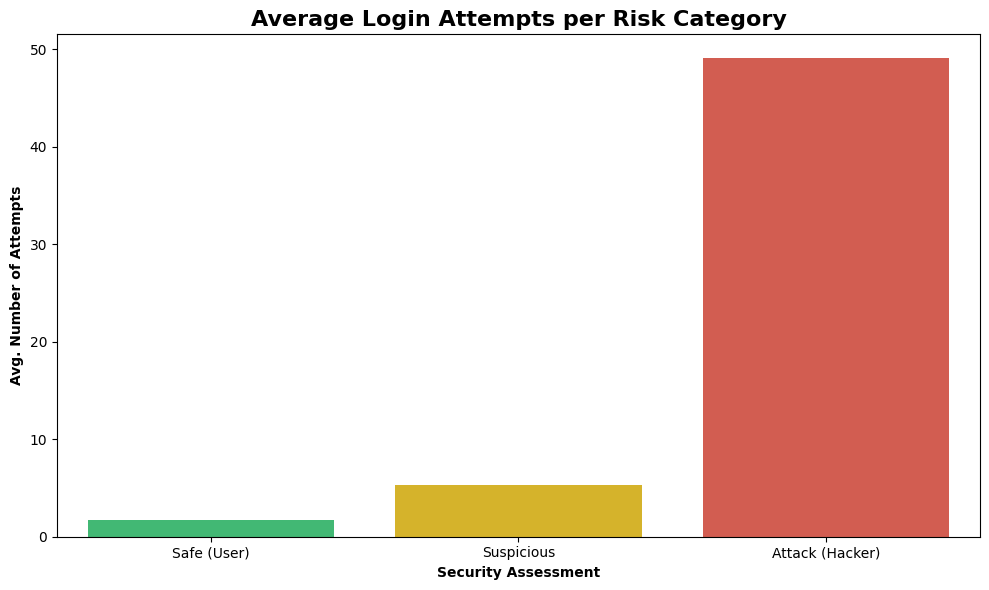

In [32]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load Data
df = pd.read_csv('cybersecurity_risk_advanced.csv')

# Program 1: Bar Chart
plt.figure(figsize=(10, 6))
colors = ['#2ecc71', '#f1c40f', '#e74c3c'] # Green, Yellow, Red

sns.barplot(data=df, x='risk_label', y='attempt_count', palette=colors, ci=None)

# Formatting for Stakeholders
plt.title('Average Login Attempts per Risk Category', fontsize=16, fontweight='bold')
plt.xticks(ticks=[0, 1, 2], labels=['Safe (User)', 'Suspicious', 'Attack (Hacker)'])
plt.xlabel('Security Assessment', fontweight='bold')
plt.ylabel('Avg. Number of Attempts', fontweight='bold')

plt.tight_layout()
plt.show()

how invisible network features (VPN AND IP trust) combine to create high-risk scenarios

C:\Users\ins1q\AppData\Local\Temp\ipykernel_23720\3576413224.py:12: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df.pivot_table(index='vpn_detected', columns='IP_Trust', values='risk_label', aggfunc='mean')


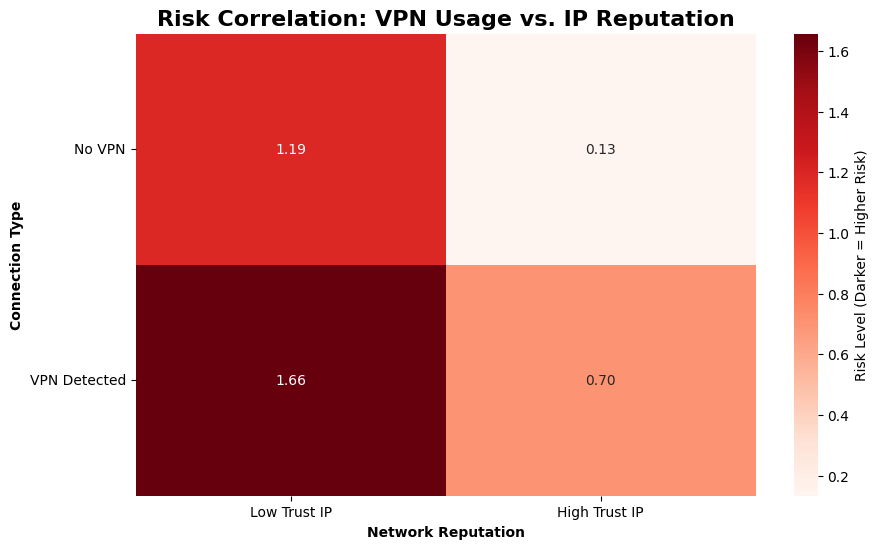

In [33]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load Data
df = pd.read_csv('cybersecurity_risk_advanced.csv')

# Simplify IP Reputation into two clear categories for the heatmap
df['IP_Trust'] = pd.cut(df['ip_reputation'], bins=[0, 0.5, 1], labels=['Low Trust IP', 'High Trust IP'])

# Aggregate the risk
pivot = df.pivot_table(index='vpn_detected', columns='IP_Trust', values='risk_label', aggfunc='mean')

# Program 2: Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, cmap='Reds', fmt='.2f', cbar_kws={'label': 'Risk Level (Darker = Higher Risk)'})

plt.title('Risk Correlation: VPN Usage vs. IP Reputation', fontsize=16, fontweight='bold')
plt.yticks(ticks=[0.5, 1.5], labels=['No VPN', 'VPN Detected'], rotation=0)
plt.xlabel('Network Reputation', fontweight='bold')
plt.ylabel('Connection Type', fontweight='bold')

plt.show()

percentage of critical attacks that happen during anamalous(night) hours

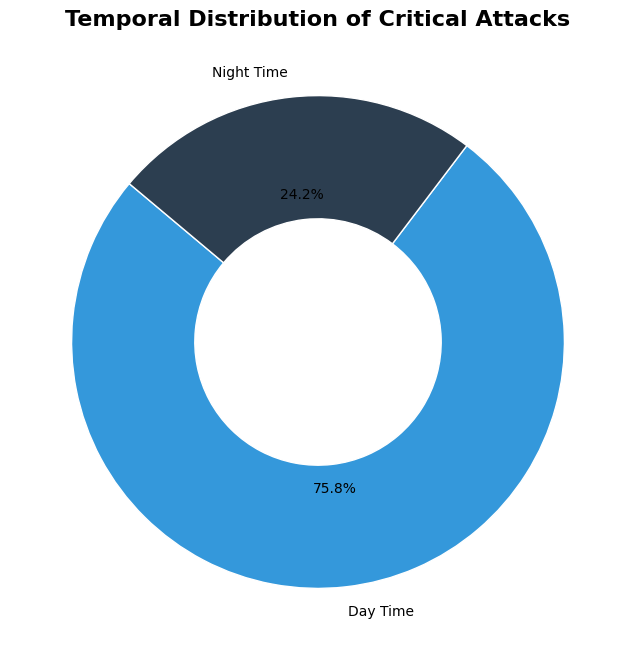

In [34]:
import pandas as pd
import matplotlib.pyplot as plt

# Load Data
df = pd.read_csv('cybersecurity_risk_advanced.csv')

# Filter for only Critical Attacks (Risk Label 2)
attack_data = df[df['risk_label'] == 2]['is_night_time'].value_counts()

# Program 3: Donut Chart
plt.figure(figsize=(8, 8))
plt.pie(attack_data, labels=['Day Time', 'Night Time'], autopct='%1.1f%%', 
        startangle=140, colors=['#3498db', '#2c3e50'], 
        wedgeprops={'edgecolor': 'white', 'width': 0.5}) # width=0.5 creates the donut hole

plt.title('Temporal Distribution of Critical Attacks', fontsize=16, fontweight='bold')
plt.show()

Which features have the highest correlation with the risk_label

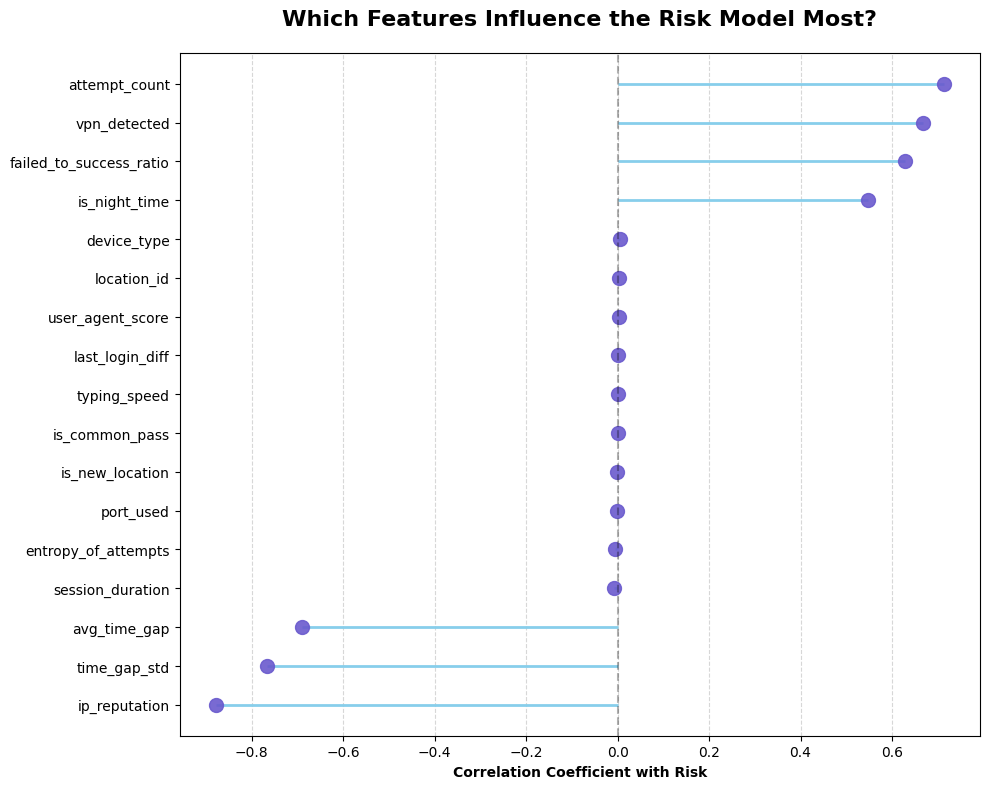

In [36]:
import pandas as pd
import matplotlib.pyplot as plt

# Load Data
df = pd.read_csv('cybersecurity_risk_advanced.csv')

# Calculate correlations with the Risk Label
correlations = df.corr()['risk_label'].drop('risk_label').sort_values(ascending=True)

# Program 6: Lollipop Chart
plt.figure(figsize=(10, 8))
plt.hlines(y=correlations.index, xmin=0, xmax=correlations.values, color='skyblue', linewidth=2)
plt.plot(correlations.values, correlations.index, "o", markersize=10, color='slateblue', alpha=0.9)

# Adding a vertical line at 0 for reference
plt.axvline(x=0, color='black', linestyle='--', alpha=0.3)

plt.title('Which Features Influence the Risk Model Most?', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Correlation Coefficient with Risk', fontweight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Proportion of each device type and within each device the breakdown of risk levels

In [37]:
import pandas as pd
import plotly.express as px

# Load Data
df = pd.read_csv('cybersecurity_risk_advanced.csv')

# Map device types for clarity
device_map = {0: 'Mobile', 1: 'Laptop', 2: 'Tablet', 3: 'Bot/Unknown'}
df['Device'] = df['device_type'].map(device_map)
df['Risk_Level'] = df['risk_label'].map({0: 'Safe', 1: 'Suspicious', 2: 'Attack'})

# Program 7: Sunburst Chart
# Note: This uses Plotly, which creates interactive, beautiful HTML-based charts
fig = px.sunburst(df, path=['Device', 'Risk_Level'], 
                  color='Risk_Level',
                  color_discrete_map={'Safe':'#2ecc71', 'Suspicious':'#f1c40f', 'Attack':'#e74c3c'},
                  title="Hierarchical Risk Analysis: Device vs. Security Status")

fig.update_layout(title_font_size=20, title_x=0.5)
fig.show()

# Model training

In [38]:
# 1. Prepare the Data
# Ensure X_scaled is a DataFrame with feature names (XGBoost likes feature names)
X_features = pd.DataFrame(X_scaled, columns=X.columns)

In [39]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X_features, y, test_size=0.2, random_state=42, stratify=y)

In [41]:
# 2. Initialize the XGBoost Classifier
# use_label_encoder=False avoids a common deprecation warning
# eval_metric='mlogloss' is for multi-class classification
import xgboost as xgb
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    use_label_encoder=False,
    eval_metric='mlogloss'
)

In [42]:
# 3. Train the model
print("Training XGBoost model...")
xgb_model.fit(X_train, y_train)

Training XGBoost model...


C:\Users\ins1q\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\xgboost\training.py:200: UserWarning: [15:56:02] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [43]:
# 4. Predictions
y_pred_xgb = xgb_model.predict(X_test)

In [45]:
# 5. Evaluate Performance
from sklearn.metrics import accuracy_score, classification_report
print("\n" + "="*30)
print(f"XGBOOST ACCURACY: {accuracy_score(y_test, y_pred_xgb)*100:.2f}%")
print("="*30)
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred_xgb, target_names=['Safe', 'Suspicious', 'Attack']))


XGBOOST ACCURACY: 97.38%

Detailed Classification Report:
              precision    recall  f1-score   support

        Safe       0.97      0.99      0.98      5874
  Suspicious       0.97      0.96      0.97      2531
      Attack       0.98      0.93      0.95      1595

    accuracy                           0.97     10000
   macro avg       0.97      0.96      0.97     10000
weighted avg       0.97      0.97      0.97     10000



Confusion matrix

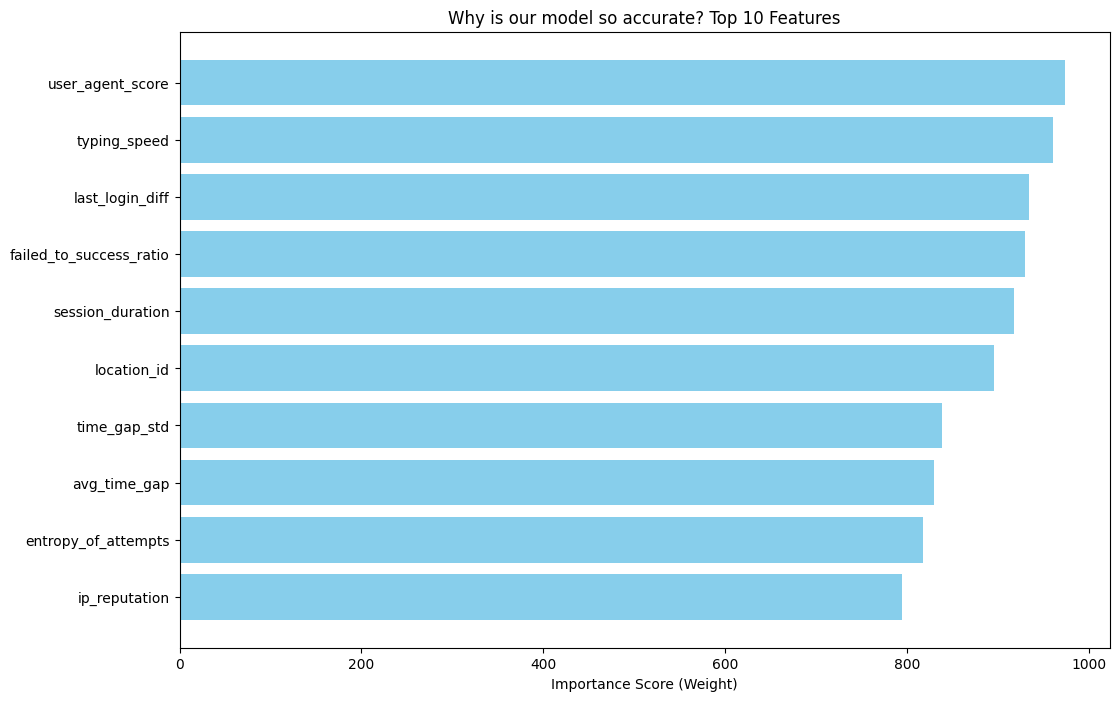

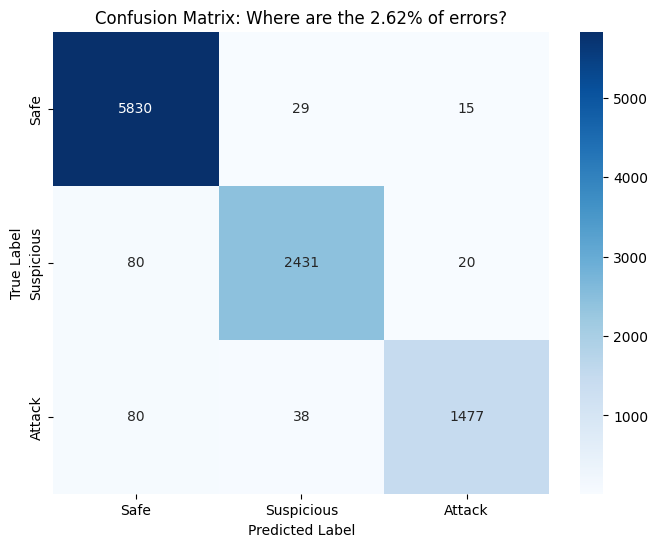

In [46]:
# 1. Visualize Feature Importance
import matplotlib.pyplot as plt

# Get feature importance
importance = xgb_model.get_booster().get_score(importance_type='weight')
importance = dict(sorted(importance.items(), key=lambda item: item[1], reverse=True))

# Plot
plt.figure(figsize=(12, 8))
plt.barh(list(importance.keys())[:10], list(importance.values())[:10], color='skyblue')
plt.xlabel('Importance Score (Weight)')
plt.title('Why is our model so accurate? Top 10 Features')
plt.gca().invert_yaxis()
plt.show()

# 2. Check the "Misses" with a Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Safe', 'Suspicious', 'Attack'], 
            yticklabels=['Safe', 'Suspicious', 'Attack'])
plt.title('Confusion Matrix: Where are the 2.62% of errors?')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [47]:
import joblib

# This uses the exact variable names from your notebook
joblib.dump(xgb_model, 'login_risk_model.pkl')
joblib.dump(scaler, 'scaler_risk.pkl')
print("✅ Login Risk model and scaler saved successfully!")

✅ Login Risk model and scaler saved successfully!
